# 👾 PixelCNN using Tensorflow distributions

In this notebook, we'll walk through the steps required to train your own PixelCNN on the fashion MNIST dataset using Tensorflow distributions

In [38]:
%pip install tensorflow tensorflow-probability

%load_ext autoreload
%autoreload 2
import numpy as np

# Force CPU-only execution in Codespaces (no CUDA) and reduce TF log noise
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU / CUDA
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # filter INFO & WARNING logs

import tensorflow as tf, tensorflow_probability as tfp
print("TF:", tf.__version__, "TFP:", tfp.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

from tensorflow.keras import datasets, layers, models, optimizers, callbacks

# Ensure project root is on sys.path so we can import from notebooks.utils
try:
    from notebooks.utils import display
except ModuleNotFoundError:
    import sys, os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    from notebooks.utils import display

Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TF: 2.20.0 TFP: 0.25.0
GPUs: []
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TF: 2.20.0 TFP: 0.25.0
GPUs: []


## 0. Parameters <a name="parameters"></a>

In [39]:
# Then edit .env to set the ports, e.g.:
# JUPYTER_PORT=8888
# TENSORBOARD_PORT=6006

In [ ]:
IMAGE_SIZE = 32
N_COMPONENTS = 5
EPOCHS = 10
BATCH_SIZE = 16  # reduce to lower memory usage
TRAIN_SAMPLES = 8000  # limit dataset size for a lighter run

## 1. Prepare the data <a name="prepare"></a>

In [41]:
# Load the data
(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

In [ ]:
# Preprocess the data

def preprocess(imgs):
    # Optional: limit data for lighter training
    if TRAIN_SAMPLES is not None:
        imgs = imgs[:TRAIN_SAMPLES]
    # Expand channels and resize to IMAGE_SIZE
    imgs = np.expand_dims(imgs, -1).astype(np.float32)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE), method='nearest')
    imgs = tf.clip_by_value(imgs, 0.0, 255.0)
    return imgs

input_data = preprocess(x_train)

# Build a tf.data pipeline to stream batches (lower memory footprint)
train_ds = (
    tf.data.Dataset.from_tensor_slices(input_data)
    .shuffle(2048)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
 )

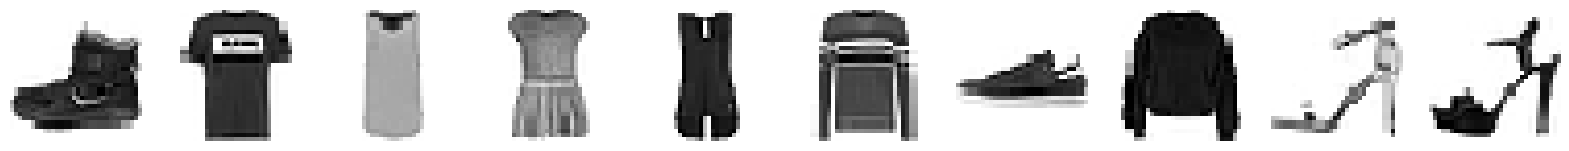

In [43]:
# Show some items of clothing from the training set
display(input_data)

## 2. Build the PixelCNN <a name="build"></a>

In [44]:
# Define a Pixel CNN network
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=1,
    num_hierarchies=2,
    num_filters=32,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
)

# Custom Keras Model that adds the negative log-likelihood as a loss
class PixelCNNModel(models.Model):
    def __init__(self, distribution):
        super().__init__()
        self.distribution = distribution
    def call(self, x, training=None):
        # Ensure float32 input as expected by internal ops
        x = tf.cast(x, tf.float32)
        log_prob = self.distribution.log_prob(x)
        self.add_loss(-tf.reduce_mean(log_prob))
        return log_prob

# Instantiate the model (it will be built on first call/fit)
pixelcnn = PixelCNNModel(dist)

## 3. Train the PixelCNN <a name="train"></a>

In [45]:
# Compile and train the model
pixelcnn.compile(
    optimizer=optimizers.Adam(0.001),
)

In [46]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def generate(self):
        return dist.sample(self.num_img).numpy()

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.generate()
        display(
            generated_images,
            n=self.num_img,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )


img_generator_callback = ImageGenerator(num_img=2)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 4291.2583

2025-10-04 22:18:40.694568: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.



Saved to ./output/generated_img_000.png


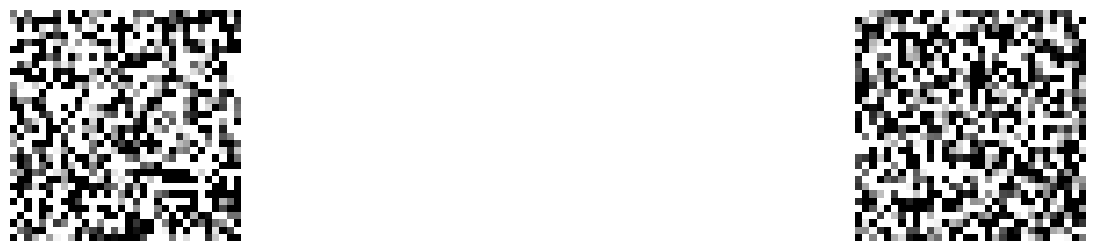

469/469 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - loss: 4289.1055


: 

In [ ]:
pixelcnn.fit(
    train_ds,
    epochs=EPOCHS,
    verbose=True,
    callbacks=[tensorboard_callback, img_generator_callback],
)

## 4. Generate images <a name="generate"></a>

In [ ]:
generated_images = img_generator_callback.generate()

In [ ]:
display(generated_images, n=img_generator_callback.num_img)